In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets.cifar10 import load_data
from matplotlib import pyplot

In [2]:
import os
import tarfile
import urllib.request
import pickle
import numpy as np

# 1. Download from fast mirror
url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"
filename = "cifar-10-python.tar.gz"

if not os.path.exists(filename):
    print("Downloading CIFAR-10 from fast mirror...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete!")

Download complete!


Extracting cifar-10-python.tar.gz...


/tmp/ipykernel_689/3185078613.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=".")


Extraction complete!

--- Data Successfully Loaded ---
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


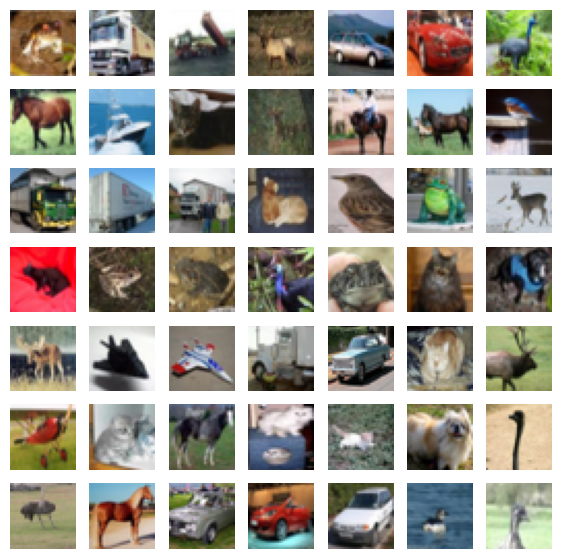

In [3]:
import tarfile
import pickle
import numpy as np
import matplotlib.pyplot as plt

print("Extracting cifar-10-python.tar.gz...")
with tarfile.open("cifar-10-python.tar.gz", "r:gz") as tar:
    tar.extractall(path=".")
print("Extraction complete!")

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

# 3. Load training batches (1 to 5)
x_train_list, y_train_list = [], []
for i in range(1, 6):
    batch_data = unpickle(f"cifar-10-batches-py/data_batch_{i}")
    x_train_list.append(batch_data[b'data'])
    y_train_list.append(batch_data[b'labels'])

x_train = np.concatenate(x_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

# Reshape x_train to image format: (50000, 32, 32, 3)
x_train = x_train.reshape((len(x_train), 3, 32, 32)).transpose(0, 2, 3, 1)

# 4. Load test batch
test_data = unpickle("cifar-10-batches-py/test_batch")
x_test = test_data[b'data']
y_test = np.array(test_data[b'labels'])
x_test = x_test.reshape((len(x_test), 3, 32, 32)).transpose(0, 2, 3, 1)

print("\n--- Data Successfully Loaded ---")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

# 5. Display the first 49 images for your GAN
plt.figure(figsize=(7, 7))
for i in range(49):
    plt.subplot(7, 7, i + 1)
    plt.axis('off')
    plt.imshow(x_train[i])
plt.show()

In [4]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D,Dense,Flatten,Dropout,LeakyReLU
from keras.utils import plot_model
import numpy as np


In [5]:
def discriminator(in_shape=(32,32,3)):
  model=Sequential()
  model.add(Conv2D(64,(3,3),padding='same',input_shape=in_shape))
  model.add(LeakyReLU(negative_slope=0.2))

  model.add(Conv2D(128,(3,3),strides=(2,2),padding='same'))
  model.add(LeakyReLU(negative_slope=0.2))

  model.add(Conv2D(128,(3,3),strides=(2,2),padding='same'))

  model.add(Conv2D(256,(3,3),strides=(2,2),padding='same'))
  model.add(LeakyReLU(negative_slope=0.2))

  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1,activation='sigmoid'))

  opt=Adam(learning_rate=0.0002 , beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=opt,metrics=['accuracy'])
  return model



In [6]:
model=discriminator()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

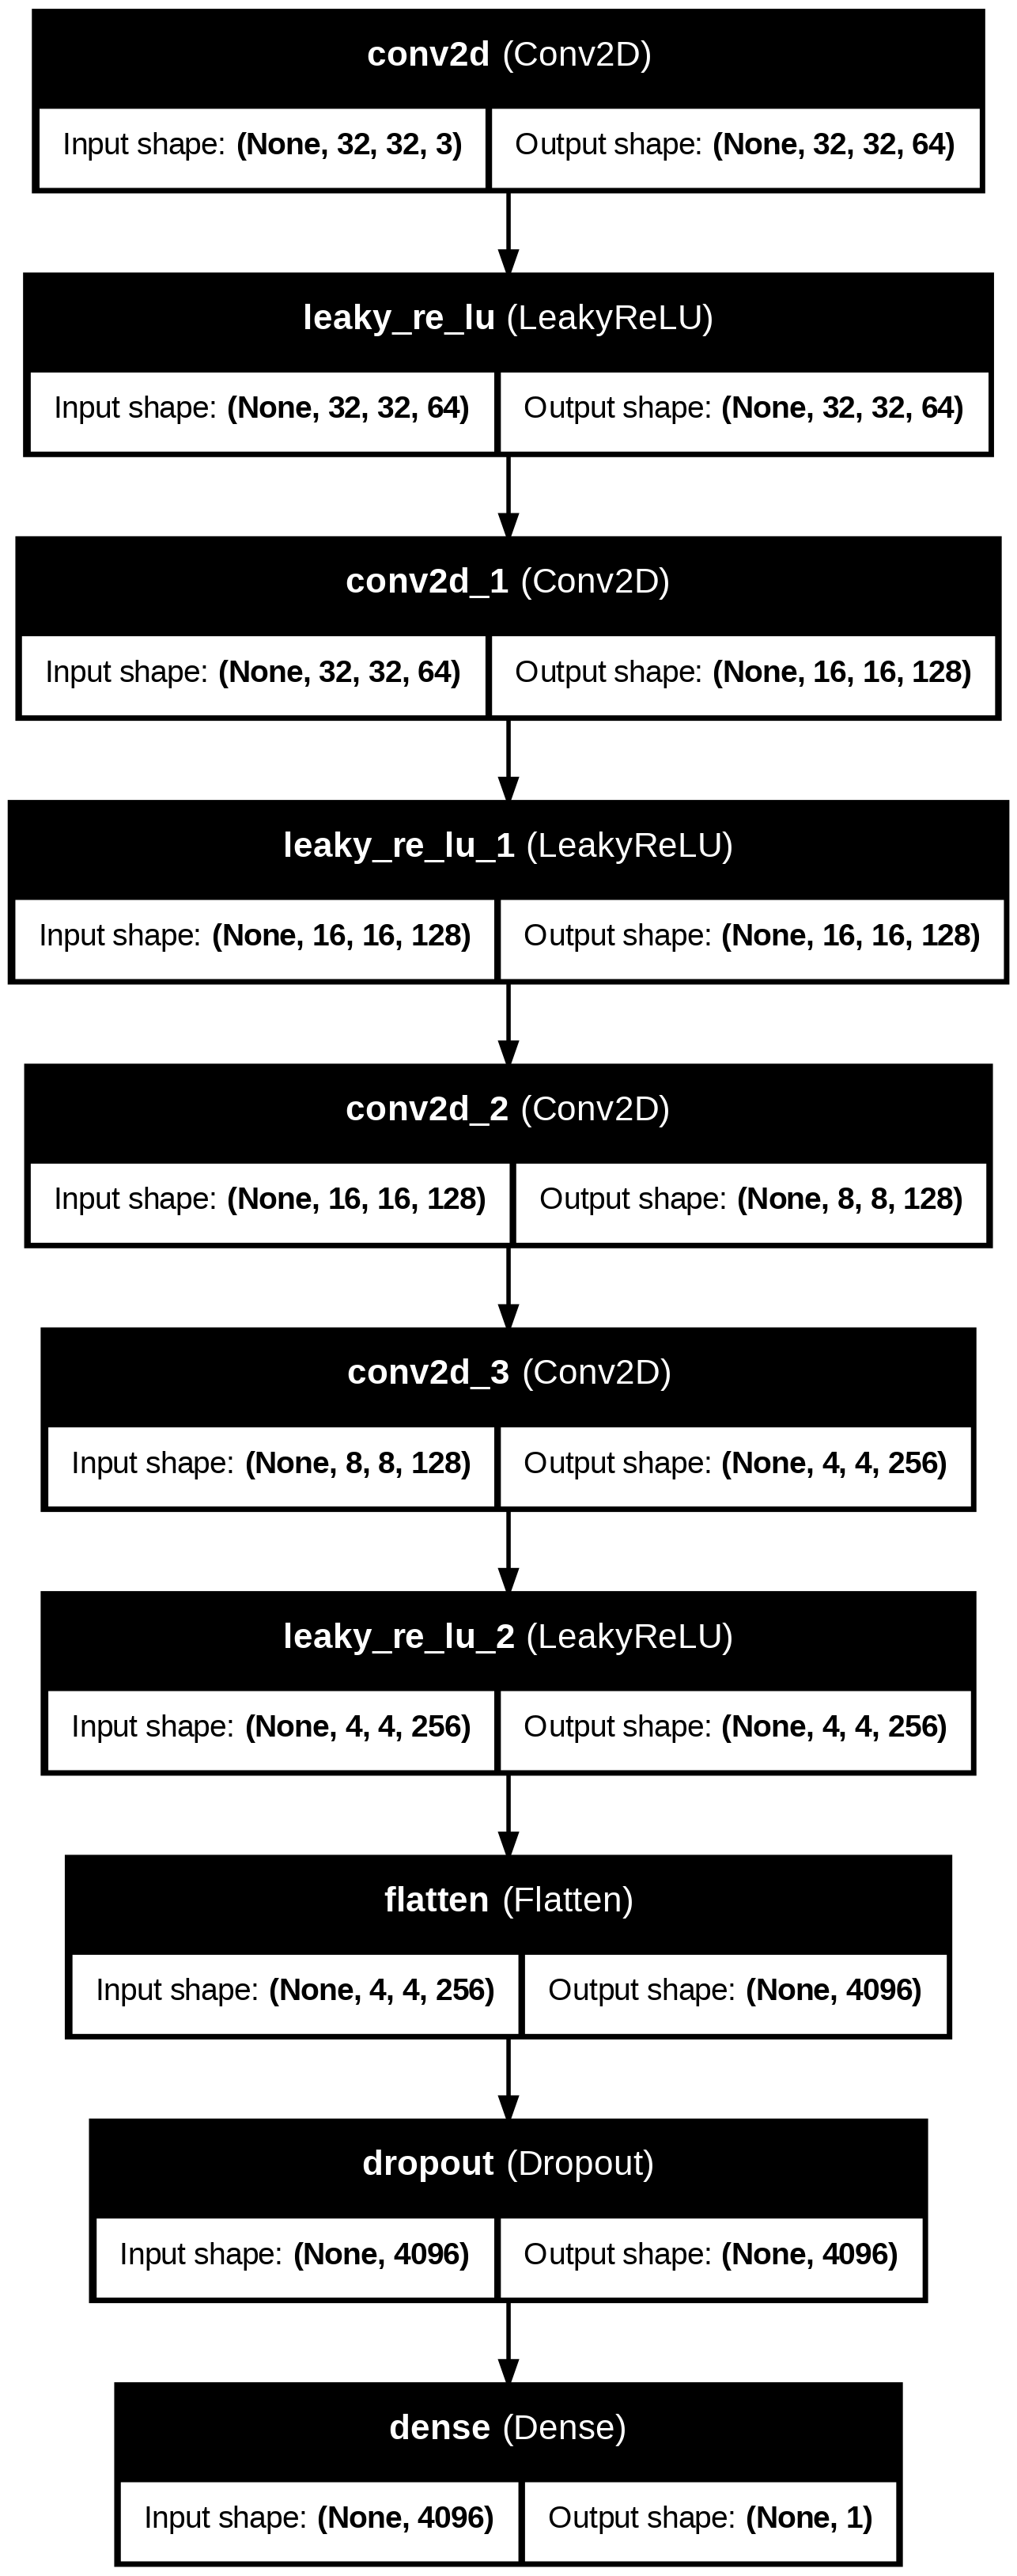

In [7]:
plot_model(model,to_file='discriminator_plot.png',show_shapes=True,show_layer_names=True)

In [8]:
def load_real_samples():
  X=x_train.astype('float32')
  X=(X-127.5)/127.5
  return X


In [9]:
X=load_real_samples()
X.shape

(50000, 32, 32, 3)

In [10]:
X[0]

array([[[-0.5372549 , -0.5137255 , -0.5058824 ],
        [-0.6627451 , -0.6392157 , -0.64705884],
        [-0.60784316, -0.62352943, -0.6627451 ],
        ...,
        [ 0.23921569,  0.03529412, -0.15294118],
        [ 0.19215687, -0.01960784, -0.2       ],
        [ 0.16078432, -0.02745098, -0.19215687]],

       [[-0.8745098 , -0.84313726, -0.84313726],
        [-1.        , -1.        , -1.        ],
        [-0.85882354, -0.9372549 , -1.        ],
        ...,
        [-0.03529412, -0.30980393, -0.5686275 ],
        [-0.06666667, -0.34901962, -0.60784316],
        [-0.04313726, -0.31764707, -0.5529412 ]],

       [[-0.8039216 , -0.8117647 , -0.8352941 ],
        [-0.8745098 , -0.94509804, -1.        ],
        [-0.6156863 , -0.7882353 , -0.9372549 ],
        ...,
        [-0.07450981, -0.34117648, -0.60784316],
        [-0.05882353, -0.34117648, -0.60784316],
        [-0.14509805, -0.42745098, -0.67058825]],

       ...,

       [[ 0.6313726 ,  0.33333334, -0.24705882],
        [ 0

In [11]:
def generate_real_images(x_trains,n_samples):
  ix=np.random.randint(0,x_trains.shape[0],n_samples)

  X=dataset[ix]
  y=np.ones((n_samples,1))
  return X,y

In [12]:

def generate_fake_images(n_samples):
    X = np.random.uniform(-1.0, 1.0, size=(n_samples, 32, 32, 3))

    y = np.zeros((n_samples, 1))

    return X, y


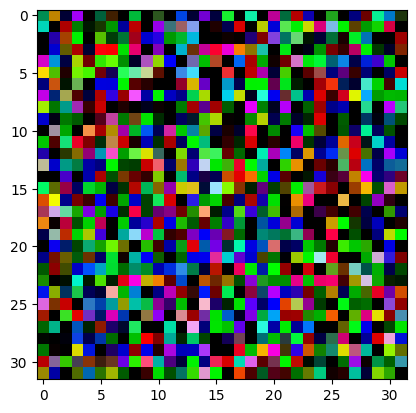

In [13]:
x,y=generate_fake_images(64)
pyplot.imshow(x[0])

In [14]:
def train_des(model,dataset,n_iter=30,n_batch=128):
  half_batch=int(n_batch/2)
  for i in range(n_iter):
    x_real,y_real=generate_real_images(dataset,half_batch)
    _,real_acc=model.train_on_batch(x_real,y_real)

    x_fake,y_fake=generate_fake_images(half_batch)
    _, fake_acc=model.train_on_batch(x_fake,y_fake)

    print('>%d real=%.0f%% fake=%.0f%%' % (i+1, real_acc*100, fake_acc*100))


In [15]:
model=discriminator()
dataset=x_train
train_des(model,x_train)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>1 real=95% fake=48%
>2 real=65% fake=50%
>3 real=60% fake=54%
>4 real=60% fake=64%
>5 real=68% fake=71%
>6 real=74% fake=76%
>7 real=78% fake=79%
>8 real=81% fake=82%
>9 real=83% fake=84%
>10 real=85% fake=85%
>11 real=86% fake=87%
>12 real=87% fake=88%
>13 real=88% fake=89%
>14 real=89% fake=90%
>15 real=90% fake=90%
>16 real=91% fake=91%
>17 real=91% fake=91%
>18 real=92% fake=92%
>19 real=92% fake=92%
>20 real=93% fake=93%
>21 real=93% fake=93%
>22 real=93% fake=93%
>23 real=94% fake=94%
>24 real=94% fake=94%
>25 real=94% fake=94%
>26 real=94% fake=94%
>27 real=94% fake=95%
>28 real=95% fake=95%
>29 real=95% fake=95%
>30 real=95% fake=95%


In [18]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Conv2D, Flatten, Dropout, LeakyReLU
from keras.utils import plot_model

# define the standalone discriminator model
def define_discriminator(in_shape=(32,32,3)):
    model = Sequential()
    # normal
    model.add(Conv2D(64, (3,3), padding='same', input_shape=in_shape))
    model.add(LeakyReLU(alpha=0.2))
    # downsample
    model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # downsample
    model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # downsample
    model.add(Conv2D(256, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # classifier
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    # compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# View the discriminator
d_model = define_discriminator()
d_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from keras.layers import Reshape, Conv2DTranspose

# define the standalone generator model
def define_generator(latent_dim):
    model = Sequential()
    # foundation for 4x4 image
    n_nodes = 256 * 4 * 4
    model.add(Dense(n_nodes, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((4, 4, 256)))
    # upsample to 8x8
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # upsample to 16x16
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # upsample to 32x32
    model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # output layer
    model.add(Conv2D(3, (3,3), activation='tanh', padding='same'))
    return model

# View the generator
latent_dim = 100
g_model = define_generator(latent_dim)
g_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model):
    # make weights in the discriminator not trainable
    d_model.trainable = False

    # connect them
    model = Sequential()
    # add generator
    model.add(g_model)
    # add the discriminator
    model.add(d_model)

    # compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

# View the GAN model
gan_model = define_gan(g_model, d_model)
gan_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 522,497 (1.99 MB)

In [21]:
def load_real_samples(x_data):
    # convert to float32 if needed
    X = x_data.astype('float32')
    # scale pixel values from [0, 255] to [-1, 1] (matches generator's tanh activation)
    X = (X - 127.5) / 127.5
    return X

def generate_real_samples(dataset, n_samples):
    # choose random image indices from dataset
    ix = np.random.randint(0, dataset.shape[0], n_samples)
    # retrieve selected images
    X = dataset[ix]
    # generate 'real' class labels (1)
    y = np.ones((n_samples, 1))
    return X, y

def generate_latent_points(latent_dim, n_samples):
    # generate points in latent space (noise)
    x_input = np.random.randn(latent_dim * n_samples)
    # reshape into a batch of inputs for the network
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

def generate_fake_samples(g_model, latent_dim, n_samples):
    # generate points in latent space
    x_input = generate_latent_points(latent_dim, n_samples)
    # predict outputs using generator
    X = g_model.predict(x_input, verbose=0)
    # create 'fake' class labels (0)
    y = np.zeros((n_samples, 1))
    return X, y

In [23]:
# Cell 7: Define the Training Loop
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=200, n_batch=128):
    bat_per_epo = int(dataset.shape[0] / n_batch)
    half_batch = int(n_batch / 2)

    # manually enumerate epochs
    for i in range(n_epochs):
        # enumerate batches over the training set
        for j in range(bat_per_epo):
            # get randomly selected 'real' samples
            X_real, y_real = generate_real_samples(dataset, half_batch)
            # update discriminator model weights
            d_loss1, _ = d_model.train_on_batch(X_real, y_real)

            # generate 'fake' examples
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
            # update discriminator model weights
            d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)

            # prepare points in latent space as input for the generator
            X_gan = generate_latent_points(latent_dim, n_batch)
            # create inverted labels for the fake samples (force the discriminator to output 1)
            y_gan = np.ones((n_batch, 1))
            # update the generator via the discriminator's error
            g_loss = gan_model.train_on_batch(X_gan, y_gan)

            # summarize loss on this batch
            if (j+1) % 50 == 0:
                print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
                    (i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))

        # evaluate the model performance every 10 epochs
        if (i+1) % 10 == 0:
            summarize_performance(i, g_model, d_model, dataset, latent_dim)

In [ ]:
# Size of the latent space
latent_dim = 100

# Normalize and scale your already loaded x_train
dataset = load_real_samples(x_train)

# Start training
train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=200, n_batch=128)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


>1, 50/390, d1=0.802, d2=0.805 g=0.522
>1, 100/390, d1=0.861, d2=0.863 g=0.452
>1, 150/390, d1=0.895, d2=0.896 g=0.417
>1, 200/390, d1=0.921, d2=0.922 g=0.391
>1, 250/390, d1=0.943, d2=0.943 g=0.373
>1, 300/390, d1=0.960, d2=0.960 g=0.358
>1, 350/390, d1=0.973, d2=0.974 g=0.347
>2, 50/390, d1=0.991, d2=0.991 g=0.332
>2, 100/390, d1=0.998, d2=0.999 g=0.326
>2, 150/390, d1=1.005, d2=1.005 g=0.321
>2, 200/390, d1=1.010, d2=1.010 g=0.317
>2, 250/390, d1=1.015, d2=1.015 g=0.313
>2, 300/390, d1=1.019, d2=1.019 g=0.310
>2, 350/390, d1=1.022, d2=1.023 g=0.307
>3, 50/390, d1=1.028, d2=1.028 g=0.302
>3, 100/390, d1=1.031, d2=1.031 g=0.300
>3, 150/390, d1=1.033, d2=1.034 g=0.298
>3, 200/390, d1=1.036, d2=1.036 g=0.297
>3, 250/390, d1=1.038, d2=1.038 g=0.295
>3, 300/390, d1=1.040, d2=1.040 g=0.293
>3, 350/390, d1=1.041, d2=1.042 g=0.292
>4, 50/390, d1=1.044, d2=1.044 g=0.290
>4, 100/390, d1=1.046, d2=1.046 g=0.289
>4, 150/390, d1=1.047, d2=1.047 g=0.288
>4, 200/390, d1=1.048, d2=1.049 g=0.287
>4, 